# Q14. Does the selected LoRA improvement hold across full validation?

Freeze the adapter promoted by [Q14 exploration](Q14-layer-adapters.ipynb) and evaluate all **17,927** July missense validation variants against its matched control and the strongest frozen control retained during exploration. No training, refitting or new checkpoint selection occurs here. This separate validation run is outside the exploratory one-hour budget.

Use **Gamow**, the prepared H100/BioNeMo runtime, and completed parent artifacts. [Protocol and reporting](src/lora_validation.py) · [GPU workflow](src/lora_validation_backend.py) · [Setup](../README.md#setup).

In [1]:
from src import lora_validation

## Freeze the selected models, full cohort and confirmation rule

Require a completed parent experiment that promoted LoRA by its declared rule. Verify its source identity, checkpoint and result hashes. Recheck Q1’s frozen full missense partitions, labels and inherited gene/component/sequence separation. Preserve the exact sources, validation order, original selection keys and selection components before scoring.

Confirmation requires all of: full-cohort LoRA **AUROC gain at least 0.005**, **no AP decrease**, and a paired AUROC **95% interval lower bound above zero** against the strongest frozen control; plus **positive AUROC gain and no AP decrease outside the 2,048 selection variants**. Report a failure of this rule as a negative confirmation result.

In [2]:
protocol = lora_validation.prepare('q14')

Frozen Q14 LoRA confirmation on all 17,927 validation variants; 15,879 outside selection and 3,246 in components absent from selection.


## Complete inference and checkpoint integrity

Score every frozen validation variant with the selected adapter, its control from the same training update count, and the strongest retained frozen classifier. Keep model, features, standardization and classifier parameters fixed. Validate exact prediction membership and labels. Erase and reload learned tensors to reproduce **64 predictions** and verify unchanged original backbone weights.

Use actual inference in a fresh kernel. Previous complete and failed validation attempts are archived, including source snapshots and real failed notebooks; the runner never uses saved result files as a substitute for this execution.

In [3]:
result = lora_validation.run_validation('q14')

Full validation: notebooks/results/q14/full/validation.log


## Full and prespecified subset results

Report AUROC/AP and paired LoRA-minus-strongest-control effects using **1,000 whole-component bootstrap resamples**, seed **42**. Repeat reporting for variants outside the selection sample and, separately, for variants belonging to components absent from that sample. The latter is descriptive and does not change the confirmation rule.

These are **development results**. The sample guided repeated model selection, and the repository has evaluated the broader validation cohort before. Neither subset is an untouched final test set; intervals do not remove selection bias.

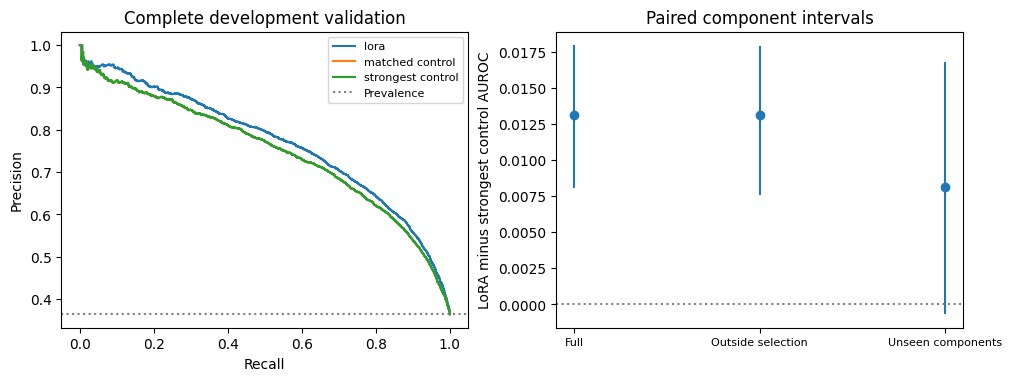

| Model | Full AUROC (95% interval) | Full AP (95% interval) |
| --- | ---: | ---: |
| lora | 0.852 [0.838, 0.865] | 0.770 [0.736, 0.797] |
| matched control | 0.839 [0.824, 0.852] | 0.749 [0.716, 0.778] |
| strongest control | 0.839 [0.824, 0.852] | 0.749 [0.716, 0.778] |

In [4]:
lora_validation.show_results('q14')

## Conclusion

Computed from complete saved predictions and the frozen confirmation rule. After this fresh notebook is saved, the runner exports full-cohort LoRA and strongest-control scores and refreshes the README comparison. A negative confirmation result remains visible.

In [5]:
lora_validation.show_conclusion('q14')

**Conclusion.** The frozen Q14 adapter **met** the prespecified full-validation confirmation rule. LoRA achieved **0.852 AUROC** and **0.770 AP** on **17,927 variants**. Its AUROC gain against the strongest frozen control was **+0.0131** (95% component interval **[+0.0080, +0.0180]**). Confirmation requires full AUROC gain at least 0.005, no AP decrease and a positive lower AUROC interval bound, plus positive AUROC gain with no AP decrease outside the selection sample. The separate validation run took **34.3 minutes**. Full frozen July missense development validation, following repeated selection on its 2,048-variant subset. Variants outside that subset and components absent from it were not used by those recent selection runs, but this repository has previously evaluated the full validation partition. Neither subset is an untouched final test set. Component-bootstrap intervals do not remove selection bias. Pretraining exposure, homology and shared-patient overlap remain unresolved; this research prototype has no clinical validation.